# task #3.3 histogram encoding
**based on**: Morris Chang, Di Zhuang, G. Dumindu Samaraweera - *Privacy-Preserving Machine Learning* (2023, Manning)

**dataset**: the titanic test file `aveshjadon/ai-impact-on-students`.

## how it works
direct encoding handled categorical data. histogram encoding handles **numerical/continuous** data — here we use `Weekly_GenAI_Hours` (continuous). histogram encoding transforms continuous numerical data into categorical features by binning values into defined intervals.

follows three steps:

1. **encoding** - bucket the numeric value, then encode it as a length-`d`
   one-hot vector: a 1.0 in the bucket the value falls in, 0.0 everywhere else.
2. **perturbation** - add laplace noise `Lap(2/eps)` to every component of the vector.
   - **SHE (summation)** keeps the noisy real numbers and just sums them.
   - **THE (thresholding)** turns each noisy component into 1.0 if it
     exceeds a threshold `theta`, else 0.0. this is the focus of this task.
3. **aggregation & estimation** - for THE, count the 1s per bucket `c_i`
   and correct the bias with `E_i = (c_i - n*q)/(p - q)`, where
   `p = 1 - 0.5*e^(eps/2*(1-theta))` and `q = 0.5*e^(eps/2*(0-theta))`.

smaller epsilon -> more laplace noise -> stronger privacy -> noisier histogram.

## import and understand dataset

In [1]:
import kagglehub

path = kagglehub.dataset_download("laveshjadon/ai-impact-on-students")
print("path to dataset files:", path)

Using Colab cache for faster access to the 'ai-impact-on-students' dataset.
path to dataset files: /kaggle/input/ai-impact-on-students


In [2]:
import os
files = os.listdir(path)
print("Files: ", files)

Files:  ['ai_student_impact_dataset (1).csv']


In [3]:
import pandas as pd
df = pd.read_csv(os.path.join(path, files[0]))

In [4]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [6]:
for i in df.columns.tolist():
  print("\nCOLUMN NAME\n", i, "\nDATA TYPE\n", df[i].dtype, "\nUNIQUE VALUES\n", df[i].unique(), "\nVALUE COUNTS\n", df[i].value_counts())
  print("________________________________________________")


COLUMN NAME
 Student_ID 
DATA TYPE
 int64 
UNIQUE VALUES
 [100001 100002 100003 ... 149998 149999 150000] 
VALUE COUNTS
 Student_ID
149984    1
149983    1
149982    1
149981    1
149980    1
         ..
100005    1
100004    1
100003    1
100002    1
100001    1
Name: count, Length: 50000, dtype: int64
________________________________________________

COLUMN NAME
 Major_Category 
DATA TYPE
 object 
UNIQUE VALUES
 ['Humanities' 'Medical' 'Business' 'STEM' 'Arts'] 
VALUE COUNTS
 Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64
________________________________________________

COLUMN NAME
 Year_of_Study 
DATA TYPE
 object 
UNIQUE VALUES
 ['Senior' 'Junior' 'Freshman' 'Sophomore' 'Graduate'] 
VALUE COUNTS
 Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64
________________________________________________

COLUMN NA

In [7]:
print(df["Weekly_GenAI_Hours"].value_counts())

Weekly_GenAI_Hours
40.00    448
0.28      81
0.33      77
0.11      73
0.95      72
        ... 
30.78      1
31.53      1
29.81      1
33.64      1
38.96      1
Name: count, Length: 3566, dtype: int64


## listing 4.11 - check column
our survey question is "how many hours per week do you use genai?" (`weekly_genai_hours`).

In [9]:
import matplotlib.pyplot as plt

count    50000.000000
mean         8.427752
std          8.269490
min          0.000000
25%          2.390000
50%          5.800000
75%         11.720000
max         40.000000
Name: Weekly_GenAI_Hours, dtype: float64


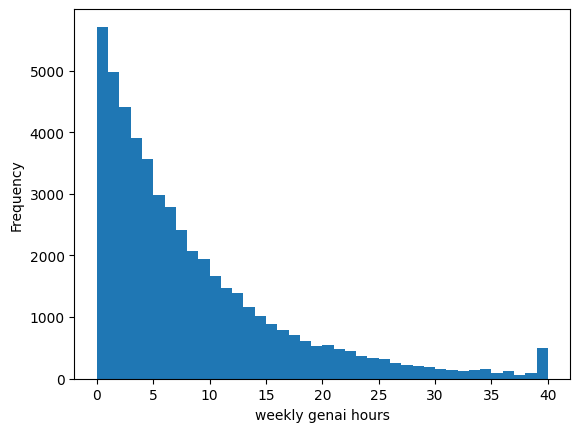

In [10]:
weekly_hours = df["Weekly_GenAI_Hours"].dropna()
print(weekly_hours.describe())
weekly_hours.plot.hist(bins=40, alpha=1.0)
plt.xlabel("weekly genai hours")
plt.show()

## listing 4.12 - input domain
our column is a float in range [0,40], so we bucket it into integer hours 0...40. each individual's value is rounded to its
bucket; the domain is the list of buckets.

In [12]:
import numpy as np

In [13]:
# transform the continuous hours into integer-hour buckets
weekly_hours = weekly_hours.round().astype(int).clip(0, 40)
domain = np.arange(0, 41)
domain.sort()
domain

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40])

## listing 4.13 - histogram encoding
encode a value as a one-hot vector over the domain.

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


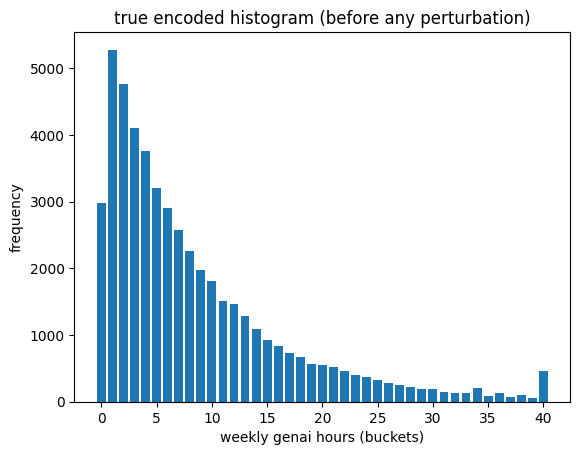

In [14]:
def encoding(answer):
    return [1.0 if d == answer else 0.0 for d in domain]

print(encoding(11))
true_hist = np.sum([encoding(r) for r in weekly_hours], axis=0)
plt.bar(domain, true_hist)
plt.ylabel("frequency")
plt.xlabel("weekly genai hours (buckets)")
plt.title("true encoded histogram (before any perturbation)")
plt.show()

## listing 4.15 - thresholding (THE)
each component gets laplace noise; then it's thresholded to 0/1 against `theta`. this is what each individual sends - already privatized client-side.

In [15]:
def the_perturb_bit(bit, epsilon=5.0, theta=1.0):
    val = bit + np.random.laplace(loc=0, scale=2 / epsilon)   # add Lap(2/eps)
    return 1.0 if val > theta else 0.0                        # threshold to 0/1

def the_perturbation(encoded_ans, epsilon=5.0, theta=1.0):
    return [the_perturb_bit(b, epsilon, theta) for b in encoded_ans]

# test: same input, different budgets
print("eps=5.0:", the_perturbation(encoding(11), epsilon=5.0)[:15], "...")
print("eps=0.1:", the_perturbation(encoding(11), epsilon=0.1)[:15], "...")

eps=5.0: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0] ...
eps=0.1: [0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0] ...


In [16]:
import math

In [17]:
def the_aggregation_and_estimation(answers, epsilon=5.0, theta=1.0):
    p = 1 - 0.5 * pow(math.e, epsilon / 2 * (1.0 - theta))
    q = 0.5 * pow(math.e, epsilon / 2 * (0.0 - theta))
    sums = np.sum(answers, axis=0)      # c_i : number of 1s per bucket
    n = len(answers)
    return [int((i - n * q) / (p - q)) for i in sums]

## before vs after with eps = 5.0

left: the raw thresholded sums (biased). right: after the estimation correction.

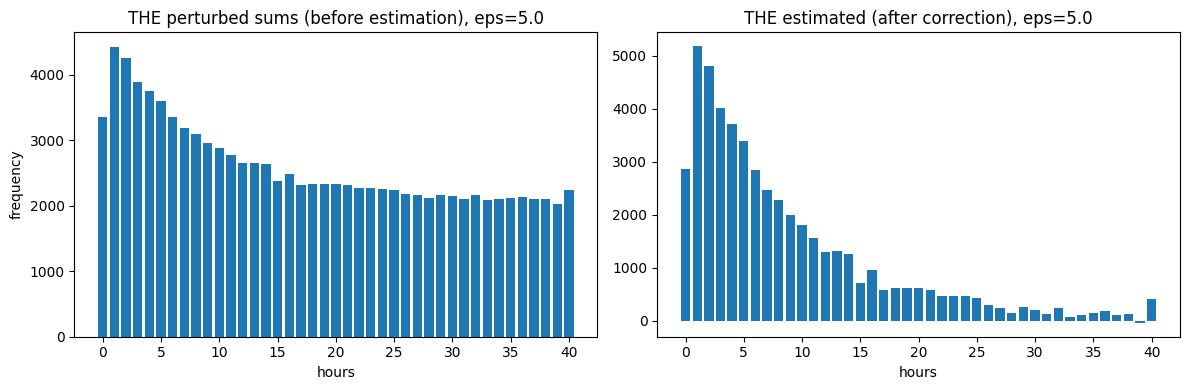

In [20]:
eps = 5.0
the_answers = [the_perturbation(encoding(r), epsilon=eps) for r in weekly_hours]
raw_sums = np.sum(the_answers, axis=0)
estimated = the_aggregation_and_estimation(the_answers, epsilon=eps)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(domain, raw_sums)
ax[0].set_title("THE perturbed sums (before estimation), eps=5.0")
ax[0].set_xlabel("hours"); ax[0].set_ylabel("frequency")
ax[1].bar(domain, estimated)
ax[1].set_title("THE estimated (after correction), eps=5.0")
ax[1].set_xlabel("hours")
plt.tight_layout()
plt.show()

## comparing several privacy budgets
run the full `THE` for several epsilon values and compare the estimated histogram against the true one. we measure mean absolute error per bucket.


In [22]:
def run_the(epsilon, theta=1.0):
    answers = [the_perturbation(encoding(r), epsilon=epsilon, theta=theta) for r in weekly_hours]
    raw = np.sum(answers, axis=0)
    est = np.array(the_aggregation_and_estimation(answers, epsilon=epsilon, theta=theta))
    return raw, est

budgets = [0.1, 0.5, 1.0, 5.0]
results = {eps: run_the(eps) for eps in budgets}

print("mean absolute error (estimated vs true histogram) by privacy budget:")
for eps in budgets:
    _, est = results[eps]
    mae = np.mean(np.abs(est - true_hist))
    print("  epsilon = {:>4} -> MAE = {:8.1f}".format(eps, mae))

mean absolute error (estimated vs true histogram) by privacy budget:
  epsilon =  0.1 -> MAE =   2909.5
  epsilon =  0.5 -> MAE =    828.1
  epsilon =  1.0 -> MAE =    401.1
  epsilon =  5.0 -> MAE =     76.6


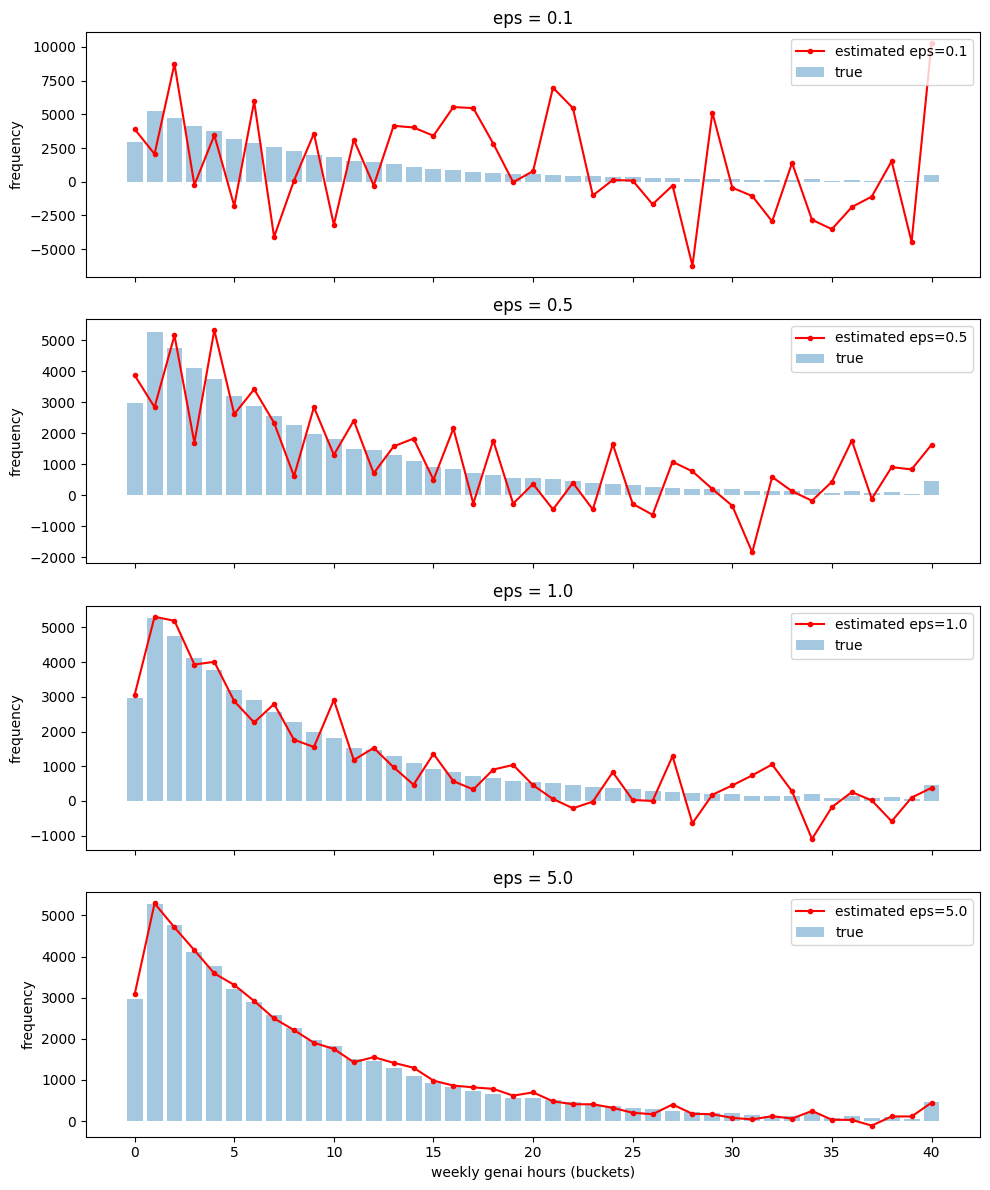

In [23]:
fig, axes = plt.subplots(len(budgets), 1, figsize=(10, 12), sharex=True)
for ax, eps in zip(axes, budgets):
    _, est = results[eps]
    ax.bar(domain, true_hist, alpha=0.4, label="true")
    ax.plot(domain, est, color="red", marker=".", label="estimated eps={}".format(eps))
    ax.set_ylabel("frequency")
    ax.legend(loc="upper right")
    ax.set_title("eps = {}".format(eps))
axes[-1].set_xlabel("weekly genai hours (buckets)")
plt.tight_layout()
plt.show()